# Cubo 3D, flujos LCT y evolución del área de una mancha solar

Este notebook explica tres pasos de un pipeline típico con datos continuos de **SDO/HMI** (`hmi.ic_45s`):

1. **Armar un cubo FITS 3D** `(tiempo, y, x)` a partir de imágenes FITS 2D individuales.
2. **Calcular flujos horizontales con LCT** (*Local Correlation Tracking*) usando `pyflowmaps`.
3. **Medir la evolución del área de la mancha** en cada frame, con el criterio `I / I_QS < 0.85`.

**Supuestos de partida.** Las imágenes 2D ya están (a) recortadas alrededor de la mancha, (b) corregidas por oscurecimiento al limbo, (c) alineadas entre sí, y (opcionalmente) (d) filtradas con el filtro subsónico. Este notebook no repite esos pasos.

> Los parámetros que debes revisar están todos en la celda de configuración de abajo.

## 0. Configuración

In [25]:
import glob, os, re
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import sunpy.map
from skimage.measure import label, regionprops

# ----------------------- RUTAS -----------------------
DATA_DIR  = r"C:\Users\juani\Documents\Biliografía_tesis\datos_tesis\sample_spot\RawContinuum\alineados_filtrados\filtrado\fits_individuales"  # dónde están los FITS 2D
FILE_GLOB = "hmi.ic_45s.*.continuum*.fits"                  # patrón de los FITS 2D (el número al final da el orden temporal)
CUBE_PATH = os.path.join(DATA_DIR, r"cubo\cubo_3d.fits")   # dónde se guardará el cubo

# ------------------- PARÁMETROS FÍSICOS -------------------
PATH_SAMPLE=r"C:\Users\juani\Documents\Biliografía_tesis\datos_tesis\sample_spot\RawContinuum\hmi.ic_45s.20110717_100000_TAI.2.continuum.fits"  # dónde está el sample
SAMPLE=sunpy.map.Map(PATH_SAMPLE)  # sample para extraer información de header
PIXSCALE = SAMPLE.scale[0].value  # arcsec / pixel (HMI)
CADENCE  = SAMPLE.meta['trecstep']  # s entre imágenes (hmi.ic_45s)

# ---------------------- LCT ----------------------
FWHM_ARCSEC = 3.0     # tamaño de la ventana gaussiana de correlación [arcsec]

# -------------------- ÁREA DE LA MANCHA --------------------
THRESH   = 0.85       # criterio: I / I_QS < THRESH
# Región de Sol en calma (QS) como (y0, y1, x0, x1) en píxeles. Debe quedar lejos de la mancha.
QS_BOX   = (174, 194, 0, 20)
MIN_AREA_PIX = 20     # ignora regiones conexas más pequeñas que esto (ruido)

---
## 1. Armar un FITS 3D a partir de FITS 2D

### Idea
Cada archivo contiene una imagen `(ny, nx)`. Un cubo es el apilamiento de todas ellas a lo largo de un eje nuevo (el tiempo), con forma `(nt, ny, nx)`. Para que el cubo sea útil hay que cuidar tres cosas:

- **Orden temporal.** `glob` devuelve los archivos en orden arbitrario, y un orden alfabético falla con números sin ceros a la izquierda (`img10` quedaría antes de `img2`). Por eso ordenamos por el **número del nombre del archivo**.
- **Mismo tamaño en todos los frames.** `np.stack` falla si una imagen tiene otra forma; conviene detectarlo antes y con un mensaje claro.
- **Dónde están los datos.** Los FITS crudos de JSOC suelen ser comprimidos y tienen los datos en la extensión 1 (`hdul[1]`), mientras que los que tú guardas con `PrimaryHDU` los tienen en la extensión 0. La función busca la primera extensión que tenga datos 2D.

In [26]:
def natural_key(path):
    # Ordena por la marca temporal AAAAMMDD_HHMMSS del nombre:
    # hmi.ic_45s.20110717_070645_TAI.2.continuum.fits -> "20110717070645"
    m = re.search(r"(\d{8})_(\d{6})", os.path.basename(path))
    if m is None:
        raise ValueError(f"No encuentro AAAAMMDD_HHMMSS en {os.path.basename(path)}")
    return m.group(1) + m.group(2)      # string de ancho fijo: ordena bien cronológicamente

def read_2d(path):
    # Devuelve (array 2D float32, header) de la primera extensión con datos 2D.
    with fits.open(path) as hdul:
        for hdu in hdul:
            if hdu.data is not None and hdu.data.ndim == 2:
                return np.asarray(hdu.data, dtype=np.float32), hdu.header.copy()
    raise ValueError(f"Sin datos 2D en {path}")

def build_cube(files):
    # Apila una lista ordenada de FITS 2D en un cubo (nt, ny, nx).
    frames, first_header = [], None
    for i, f in enumerate(files):
        img, hdr = read_2d(f)
        if i == 0:
            first_header, shape0 = hdr, img.shape
        elif img.shape != shape0:
            raise ValueError(f"{os.path.basename(f)} tiene forma {img.shape}, se esperaba {shape0}")
        frames.append(img)
    return np.stack(frames, axis=0), first_header

In [27]:
files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_GLOB)), key=natural_key)
print(f"{len(files)} archivos encontrados")
print("primero:", os.path.basename(files[0]))
print("último :", os.path.basename(files[-1]))

cube, hdr0 = build_cube(files)
print("forma del cubo (nt, ny, nx):", cube.shape)
print("NaN en el cubo:", int(np.isnan(cube).sum()))

478 archivos encontrados
primero: hmi.ic_45s.20110717_070045_TAI.2.continuum.fits
último : hmi.ic_45s.20110717_125915_TAI.2.continuum.fits
forma del cubo (nt, ny, nx): (478, 196, 196)
NaN en el cubo: 0


### Guardar el cubo
Escribimos el cubo en una `PrimaryHDU` y añadimos en el header lo que otras herramientas necesitan para interpretar los ejes (escala espacial y cadencia). Además guardamos la lista de archivos de origen en una segunda extensión, para no perder la trazabilidad de cada frame.

In [28]:
hdu = fits.PrimaryHDU(cube)
hdu.header["CDELT1"] = (PIXSCALE, "arcsec/pixel eje x")
hdu.header["CDELT2"] = (PIXSCALE, "arcsec/pixel eje y")
hdu.header["CDELT3"] = (CADENCE,  "s entre frames")
hdu.header["CTYPE3"] = "TIME"
for k in ("DATE-OBS", "T_OBS", "T_REC"):          # fecha del primer frame, si existe
    if k in hdr0:
        hdu.header["T_FIRST"] = (str(hdr0[k]), f"{k} del primer frame"); break

names = fits.BinTableHDU.from_columns(
    [fits.Column(name="FILE", format="128A", array=np.array([os.path.basename(f) for f in files]))],
    name="FILES")

fits.HDUList([hdu, names]).writeto(CUBE_PATH, overwrite=True)
print("Cubo guardado en:", CUBE_PATH)

Cubo guardado en: C:\Users\juani\Documents\Biliografía_tesis\datos_tesis\sample_spot\RawContinuum\alineados_filtrados\filtrado\fits_individuales\cubo\cubo_3d.fits


---
## 2. Flujos horizontales con LCT (`pyflowmaps`)

### Idea
*Local Correlation Tracking* estima cuánto se desplazó cada punto de la imagen entre frames consecutivos. Para cada píxel se toma una **ventana gaussiana** (de ancho `FWHM_ARCSEC`) y se busca el desplazamiento que maximiza la correlación entre una imagen y la siguiente. Dividiendo ese desplazamiento entre la cadencia se obtiene la velocidad. El resultado son dos mapas, `vx` y `vy`, en **km/s**.

La llamada es:

```python
flows = flowLCT(cubo, FWHM_ARCSEC, PIXSCALE, CADENCE)
```

con estos argumentos:

| argumento | significado | valor aquí |
|---|---|---|
| `cubo` | array `(nt, ny, nx)` | el cubo del paso 1 |
| `FWHM_ARCSEC` | ancho de la ventana de correlación [arcsec] | 3 |
| `PIXSCALE` | arcsec por píxel | 0.50433 |
| `CADENCE` | segundos entre frames | 45 |

**Qué esperar de las entradas.** LCT sigue patrones de granulación, así que el cubo debe estar **alineado** (si no, el movimiento del telescopio o de la mancha completa contamina todo). Además, el filtro subsónico elimina las oscilaciones p-mode, que de otro modo aparecen como un ruido de velocidad con periodo de 5 min.

**Un detalle importante.** El mapa de salida puede ser algo más pequeño que el de entrada (en tus datos se pasa de 199 a 196 píxeles), porque se descartan bordes. Hay que revisar las formas antes de superponer los flujos sobre las imágenes.

### Instalación de `pyflowmaps`

Antes de ejecutar el código, abrir una terminal y ejecutar:

```bash
cd pyflowmaps

pip install .

# Para una instalación de desarrollo:
pip install -e .

# Con soporte opcional para SunPy:
pip install ".[sunpy]"

In [30]:
from pyflowmaps.flow import flowLCT

flows = flowLCT(cube, FWHM_ARCSEC, PIXSCALE, CADENCE)

vx, vy = np.asarray(flows.vx), np.asarray(flows.vy)
speed  = np.hypot(vx, vy)

print("forma del cubo de entrada :", cube.shape)
print("forma del mapa de flujo   :", vx.shape)
print(f"velocidad media  : {np.nanmean(speed):.3f} km/s")
print(f"velocidad máxima : {np.nanmax(speed):.3f} km/s")
print("NaN en el mapa   :", int(np.isnan(speed).sum()))

forma del cubo de entrada : (478, 196, 196)
forma del mapa de flujo   : (196, 196)
velocidad media  : 0.142 km/s
velocidad máxima : 0.420 km/s
NaN en el mapa   : 0


### Visualizar
LCT entrega **un único mapa de flujo para todo el cubo** (promedia en el tiempo), así que lo superponemos sobre la imagen promedio de la mancha. Como el mapa de flujo puede ser más pequeño, recortamos la imagen de fondo al mismo tamaño centrándola.

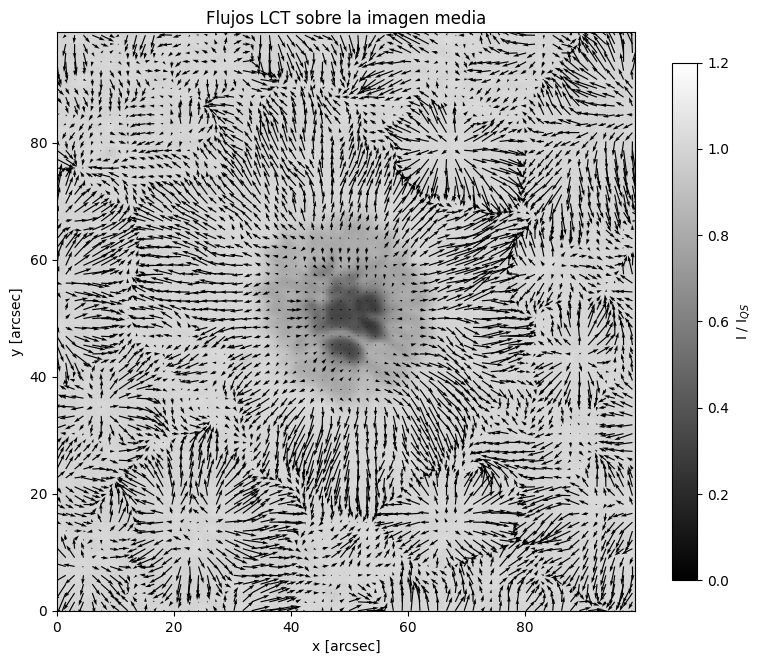

In [43]:
ny, nx = vx.shape
cy, cx = (cube.shape[1] - ny) // 2, (cube.shape[2] - nx) // 2

# Imagen media del cubo completo, normalizada por la intensidad del Sol en calma
y0, y1, x0, x1 = QS_BOX
mean_full = np.nanmean(cube, axis=0)
I_QS = np.nanmean(mean_full[y0:y1, x0:x1])
mean_img = (mean_full / I_QS)[cy:cy+ny, cx:cx+nx]              # I/I_QS recortada al tamaño del flujo

yy, xx = np.mgrid[0:ny, 0:nx]
x_as, y_as = xx * PIXSCALE, yy * PIXSCALE
step = 3                                                       # una flecha cada 'step' píxeles
extent = [0, nx*PIXSCALE, 0, ny*PIXSCALE]

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(mean_img, cmap="gray", origin="lower", extent=extent, vmin=0, vmax=1.2)
ax.quiver(x_as[::step, ::step], y_as[::step, ::step],
          vx[::step, ::step], vy[::step, ::step],
          color="black", scale=7, width=0.002)

ax.set_title("Flujos LCT sobre la imagen media")
ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
plt.colorbar(im, ax=ax, label="I / I$_{QS}$", shrink=0.8)
plt.tight_layout(); plt.show()

**Para interpretar.** En una mancha bien resuelta suele verse el **flujo de moat** (hacia afuera) alrededor de la  penumbra y flujos moderados y desordenados en la umbra. Velocidades medias del orden de 0.1 km/s son habituales en granulación. Si los vectores apuntan todos en la misma dirección, sospecha de una alineación defectuosa del cubo.

*Nota:* estos flujos son **proyectados** sobre el plano del cielo. Si la mancha está lejos del centro del disco, necesitas deproyectarlos (como hacías con `deproj_vel`).

---
## 3. Evolución del área de la mancha frame a frame

### Criterio
En cada frame:

1. **Normalizar** la imagen por la intensidad del Sol en calma: `I / I_QS`, con `I_QS` = media de `QS_BOX`, una región sin manchas. Así la fotosfera en calma vale ≈ 1.
2. **Umbral**: un píxel pertenece a la mancha si `I / I_QS < 0.85` (umbra + penumbra).
3. **Región conexa más grande**: se etiquetan las regiones conectadas de la máscara (`skimage.measure.label`) y se toma la de mayor área, para descartar poros, gránulos oscuros o ruido aislado.
4. **Área** = (número de píxeles) × (`PIXSCALE`)², en arcsec².

### Qué cambia respecto al código original
Tu código original usaba `I/I_QS < thresh * np.mean(I/I_QS)`, es decir, normalizaba **dos veces**: el umbral efectivo dependía de la media de todo el recorte (que incluye la mancha), y por eso cambiaba según el tamaño del campo de visión. Aquí se aplica el criterio directamente: `I/I_QS < 0.85`.

Además, `I_QS` se calcula **en cada frame** y no solo en el frame 15. Así se compensan variaciones lentas de brillo del recorte.

In [33]:
def sunspot_area_series(cube, qs_box, thresh=0.85, pixscale=0.50433, min_area_pix=20):
    # Área de la mancha (región conexa más grande con I/I_QS < thresh) en cada frame.
    # Devuelve dict con: area_arcsec2, area_pix, i_qs y masks (nt, ny, nx) bool.
    y0, y1, x0, x1 = qs_box
    nt = cube.shape[0]
    area_pix = np.zeros(nt, dtype=int)
    i_qs     = np.zeros(nt)
    masks    = np.zeros(cube.shape, dtype=bool)

    for k in range(nt):
        frame = cube[k]
        i_qs[k] = np.nanmean(frame[y0:y1, x0:x1])
        norm = frame / i_qs[k]

        mask = norm < thresh                      # NaN < x es False, no entra en la máscara
        lab  = label(mask)                        # conectividad por defecto: 8 vecinos en 2D (full)
        regs = [r for r in regionprops(lab) if r.area >= min_area_pix]
        if not regs:
            continue                              # frame sin mancha detectada: área 0
        biggest = max(regs, key=lambda r: r.area)
        masks[k] = lab == biggest.label
        area_pix[k] = biggest.area

    return {"area_pix": area_pix,
            "area_arcsec2": area_pix * pixscale**2,
            "i_qs": i_qs,
            "masks": masks}

### Paso previo: comprobar la región de Sol en calma
Antes de medir nada hay que verificar que `QS_BOX` cae en fotosfera tranquila (sin umbra, penumbra ni poros). Si cae sobre algo oscuro, todo el cálculo queda sesgado.

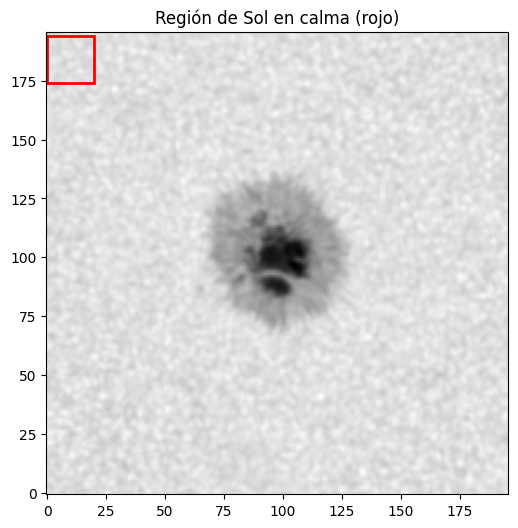

I_QS (frame 0) = 65361.8


In [44]:
y0, y1, x0, x1 = QS_BOX
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cube[0], cmap="gray", origin="lower")
ax.add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, ec="red", lw=2))
ax.set_title("Región de Sol en calma (rojo)")
plt.show()
print(f"I_QS (frame 0) = {np.nanmean(cube[0][y0:y1, x0:x1]):.1f}")

In [35]:
res = sunspot_area_series(cube, QS_BOX, THRESH, PIXSCALE, MIN_AREA_PIX)

area   = res["area_arcsec2"]
t_min  = np.arange(cube.shape[0]) * CADENCE / 60.0      # minutos desde el primer frame

print(f"Área inicial : {area[0]:.1f} arcsec²")
print(f"Área final   : {area[-1]:.1f} arcsec²")
print(f"Área media   : {area.mean():.1f} ± {area.std():.1f} arcsec²")
print(f"Frames sin mancha: {(res['area_pix'] == 0).sum()}")

Área inicial : 602.9 arcsec²
Área final   : 602.4 arcsec²
Área media   : 589.7 ± 12.7 arcsec²
Frames sin mancha: 0


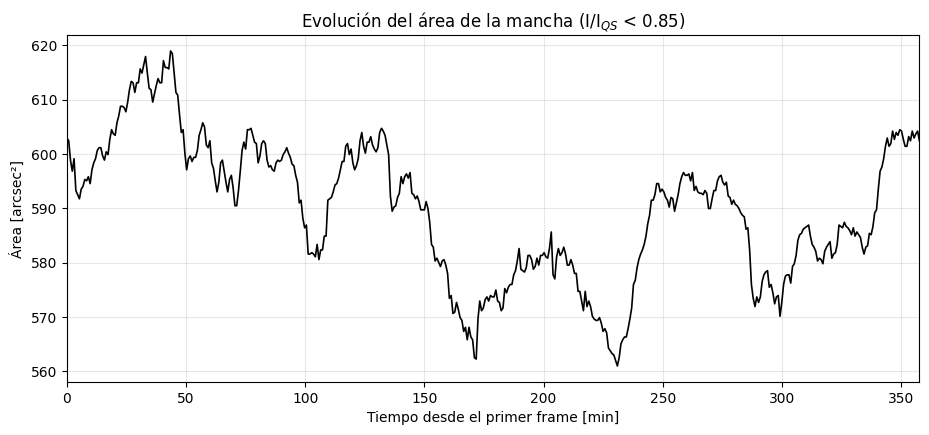

In [36]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_min, area, color="k", lw=1.2)
ax.set_xlabel("Tiempo desde el primer frame [min]")
ax.set_ylabel("Área [arcsec²]")
ax.set_title(f"Evolución del área de la mancha (I/I$_{{QS}}$ < {THRESH})")
ax.grid(alpha=0.3); ax.set_xlim(t_min[0], t_min[-1])
plt.show()

### Verificación visual
Una curva suave no garantiza que la máscara sea correcta. Siempre conviene mirar los contornos sobre las imágenes reales en algunos frames.

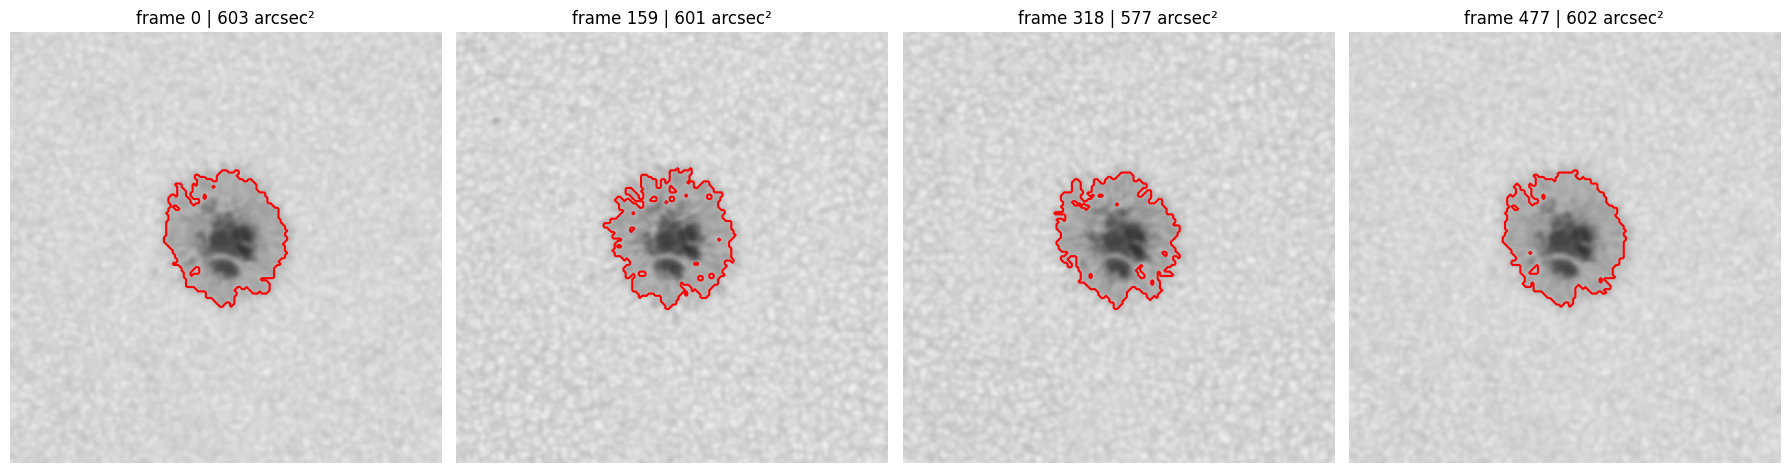

In [37]:
frames_show = np.linspace(0, cube.shape[0]-1, 4).astype(int)
fig, axs = plt.subplots(1, 4, figsize=(18, 4.8))
for ax, k in zip(axs, frames_show):
    ax.imshow(cube[k] / res["i_qs"][k], cmap="gray", origin="lower", vmin=0, vmax=1.2)
    ax.contour(res["masks"][k].astype(float), levels=[0.5], colors="r", linewidths=1.5)
    ax.set_title(f"frame {k} | {area[k]:.0f} arcsec²")
    ax.axis("off")
plt.tight_layout(); plt.show()

### Guardar la serie

### Limitaciones a tener en cuenta

- **Área proyectada.** Los arcsec² medidos son los del plano del cielo. Si la mancha no está en el centro del disco, el área real es mayor por el *foreshortening*: divide entre `cos(θ)`, donde θ es la distancia angular al centro del disco. Para pasar a Mm² usa ≈ 0.725 Mm por arcsec.
- **Sensibilidad al umbral.** 0.85 incluye penumbra; la umbra pura suele tomarse en ~0.5–0.6. Prueba umbrales cercanos para ver cuánto cambia el resultado.
- **Fragmentación.** Si la mancha se parte en piezas durante la evolución, la "región conexa más grande" puede saltar de una pieza a otra y producir caídas bruscas en el área. Si ocurre, suma todas las regiones por encima de `MIN_AREA_PIX` o ajusta la conectividad.
- **Bordes del recorte.** Una mancha que toca el borde de la imagen queda truncada, y su área se subestima.
- **Ruido de alta frecuencia.** Si la curva es muy ruidosa, un suavizado temporal (media móvil de ~10 frames = 7.5 min) puede ayudar para análisis, pero conviene guardar siempre la serie sin suavizar.